# Input:

## import

In [1]:
from sklearn.exceptions import DataConversionWarning
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)

In [2]:
import torch
import torch.nn as nn
from torch.distributions import Categorical
import numpy as np
import gym

## Data Preparation:

In [3]:
import pandas as pd
import numpy as np

data = pd.read_csv("/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /Data Set/DL_aapl_Training_Data.csv")
data = data.set_index("Date")

training_data = data.loc[:, ~data.columns.isin(["target", "strength target", "regression target"])].copy()
target= data.loc[:, ["target"]].copy()

data.head()
display(training_data.shape, target.shape)

(10964, 93)

(10964, 1)

['volatility_bbhi', 'volatility_bbli', 'volatility_kchi', 'volatility_kcli', 'trend_psar_up_indicator', 'trend_psar_down_indicator']


Text(0, 0.5, 'Price')

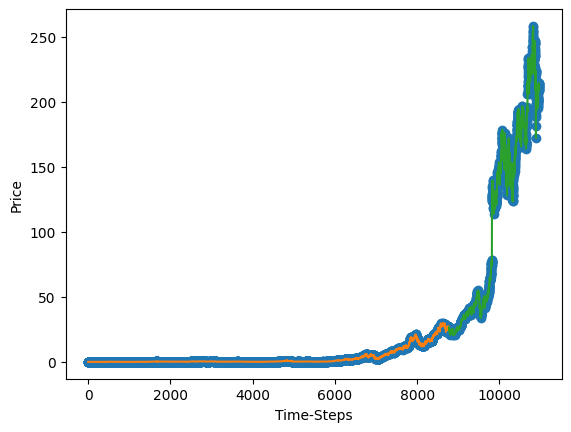

In [4]:
def data_split(split_percentage, df):

    assert 0 < split_percentage < 1, "split_percentage must be a float between 0 and 1 (exclusive)"
    
    split_index = int(len(df) * split_percentage)

    train_df = df.iloc[:split_index].copy()
    test_df = df.iloc[split_index:].copy()
    
    return train_df, test_df

def define_rule_based_indicators_list(X):
    rule_based_indicators =[]
    for col in X.columns:
        if len(X[col].unique()) <= 2:
            rule_based_indicators.append(col)
    
    return rule_based_indicators

print(define_rule_based_indicators_list(training_data))

#X, Valid_set, y, Valid_result = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
X, Valid_set = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
y, Valid_result = target.reset_index(drop=True).loc[X.index], target.reset_index(drop=True).loc[Valid_set.index]
from matplotlib import pyplot as plt

df = training_data.reset_index(drop=True)
price = df.loc[:, 'close']
plt.plot(price.index, price.values, 'o')

for df in [X, Valid_set]:
    price = df.loc[:, 'close']
    plt.plot(price.index, price.values)
    
plt.xlabel("Time-Steps")
plt.ylabel("Price")

# M1 layers processing:

## Fold CV fucntion:

In [5]:
def purged_kfold_split(X, n_splits=5, lookahead=5, embargo=0):
    fold_size = len(X) // n_splits
    for i in range(n_splits):
        test_start = i * fold_size
        test_end = (i + 1) * fold_size

        # Embargo
        embargo_start = test_end + 1
        embargo_end = embargo_start + embargo

        # Purge overlaps
        train_idx = list(range(0, test_start - lookahead)) + list(range(embargo_end, len(X)))
        test_idx = list(range(test_start, test_end))

        yield train_idx, test_idx

## Adding models:

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
import joblib

model_paths = ["knn_model_with_threshold.pkl", "logr_model_with_threshold.pkl", "rf_model_with_threshold.pkl", "xgb_model_with_threshold.pkl"]
model_names = ["KNNs", "LogR", "RF", "XGB"]
model_infor = {}

for name, path in zip(model_names, model_paths):
    model_infor[name] = joblib.load(f"/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/{path}")

In [7]:
for key, infor in model_infor.items():
    print(f"{key}: {infor["model"]}")

KNNs: KNeighborsClassifier(algorithm='kd_tree', leaf_size=16, n_jobs=-1,
                     n_neighbors=3, p=1)
LogR: LogisticRegression(C=1.8727005942368125, class_weight='balanced',
                   l1_ratio=0.9507143064099162, max_iter=1000, random_state=42,
                   solver='saga')
RF: RandomForestClassifier(class_weight='balanced', max_depth=3,
                       max_features=0.9729188669457949, min_samples_leaf=8,
                       min_samples_split=5, n_estimators=95, n_jobs=-1,
                       random_state=42)
XGB: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.18485445552552704, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=9.695846277645586, grow_policy=None, importance_type=None,
              interaction_con

## M1-models Processing:

In [8]:
from sklearn.metrics import f1_score

sub_training_data = X.copy()
sub_testing_data = Valid_set.copy()

for name, infor in model_infor.items():
    model = infor["model"]
    
    # record in the train-set
    X_train_1 = X.loc[:, infor["feature set"]].copy()
    model.fit(X_train_1, y)
    
    y_proba = model.predict_proba(X_train_1)[:, 1]
    sub_training_data[f"{name}_proba"] = y_proba
    
    '''
    y_pred = (y_proba > infor["threshold"]).astype(int)
    '''
    y_pred = model.predict(X_train_1)
    sub_training_data[f"{name}_prediction"] = y_pred
    #sub_training_data[f"{name}_valid"] = ( y_pred == y.to_numpy().T[0] ).astype(int)
    
    print()
    print( f"{name}_f1_score: {f1_score(y_true=y, y_pred=y_pred)}" )
    print(np.unique(y_pred, return_counts=True))
    
    # record in the test-set
    X_test_1 = Valid_set.loc[:, infor["feature set"]].copy()
    
    y_proba = model.predict_proba(X_test_1)[:, 1]
    sub_testing_data[f"{name}_proba"] = y_proba
    
    '''
    y_pred = (y_proba > infor["threshold"]).astype(int)
    '''
    y_pred = model.predict(X_test_1)
    sub_testing_data[f"{name}_prediction"] = y_pred
    
    print( f"{name}_f1_score: {f1_score(y_true=Valid_result, y_pred=y_pred)}" )
    print(np.unique(y_pred, return_counts=True))

KeyError: "['month', 'weekday', 'monday_morning'] not in index"

In [ ]:
display(sub_training_data.head())
display(sub_testing_data.head())

,close,high,low,open,volume,return,log_return,volume_adi,volume_obv,volume_cmf,...,others_dlr,others_cr,KNNs_proba,KNNs_prediction,LogR_proba,LogR_prediction,RF_proba,RF_prediction,XGB_proba,XGB_prediction
0,0.090881,0.091738,0.090881,0.090881,14761600,0.003001,0.033583,-2.260698e+09,311852800.0,-1.0,...,-3.696273,-10.869671,0.413793,0.0,0.398843,0.0,0.696969,1.0,0.488488,0
1,0.091310,0.091738,0.091310,0.091310,11760000,0.000429,0.004706,-2.275459e+09,326614400.0,-1.0,...,-5.593288,-7.825612,0.379310,0.0,0.417983,0.0,0.152979,0.0,0.468734,0
2,0.090024,0.090452,0.090024,0.090452,16172800,-0.001286,-0.014184,-2.287219e+09,338374400.0,-1.0,...,-5.923888,-7.390857,0.413793,0.0,0.398324,0.0,0.152757,0.0,0.468734,0
3,0.089165,0.089594,0.089165,0.089594,13708800,-0.000858,-0.009578,-2.303392e+09,322201600.0,-1.0,...,3.686817,-8.695108,0.344828,0.0,0.380432,0.0,0.120897,0.0,0.468734,0
4,0.088737,0.089165,0.088737,0.089165,5376000,-0.000429,-0.004819,-2.317101e+09,308492800.0,-1.0,...,3.555726,-9.565443,0.275862,0.0,0.408050,0.0,0.128748,0.0,0.468734,0


,close,high,low,open,volume,return,log_return,volume_adi,volume_obv,volume_cmf,...,others_dlr,others_cr,KNNs_proba,KNNs_prediction,LogR_proba,LogR_prediction,RF_proba,RF_prediction,XGB_proba,XGB_prediction
8771,26.724617,27.081608,26.618423,26.882779,128336800,-0.169455,-0.006321,-5.257941e+10,2.191406e+11,-0.129969,...,0.115724,27176.862138,0.551724,1.0,0.468795,0.0,0.434384,0.0,0.498136,0
8772,26.713326,26.796924,26.403782,26.552904,137238000,-0.011292,-0.000423,-5.257941e+10,2.190122e+11,-0.085456,...,-0.405557,27004.995671,0.517241,1.0,0.475845,0.0,0.416451,0.0,0.498136,0
8773,26.123610,26.591313,26.001600,26.580015,185445600,-0.589716,-0.022323,-5.257941e+10,2.188750e+11,-0.100147,...,-3.202429,26993.543452,0.482759,0.0,0.514863,1.0,0.515350,1.0,0.498136,0
8774,26.247877,26.421855,26.098755,26.218505,116850800,0.124268,0.004746,-5.257941e+10,2.186896e+11,-0.093902,...,-0.566844,26395.433908,0.448276,0.0,0.501799,1.0,0.431905,0.0,0.488488,0
8775,25.572302,26.071637,25.497740,26.026449,187544800,-0.675575,-0.026075,-5.257941e+10,2.188064e+11,-0.100272,...,-0.336430,26521.470220,0.482759,0.0,0.514723,1.0,0.497604,0.0,0.498136,0


## dataframe set-up with the m1 layers:

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import cross_val_score

def voting_method(data):
    score_array = []
    X_meta = []
    for name, infor in model_infor.items():
        
        '''
        y_pred= sub_training_data[f"{name}_prediction"]
        score = f1_score(y_pred=y_pred, y_true= y) 
        '''
        
        cv = purged_kfold_split(X.copy())
        score = cross_val_score(estimator=infor["model"], X=X.loc[:, infor["feature set"]].copy(), y=y.copy(), cv=cv, scoring="f1", n_jobs=-1).mean()
        score_array.append( score )
        
        X_meta.append(data[f"{name}_prediction"].tolist())
        print(f"{name}: {score_array[-1]}")

    # Weighted predictions (element-wise multiplication)
    score_array = np.array(score_array)
    #normalized_weights = score_array / score_array.sum()
    normalized_weights = score_array

    X_weighted = np.array(X_meta) * normalized_weights.reshape(4,1)
    
    # Same preds array as above
    weighted_votes = np.dot(X_weighted.T, normalized_weights)  # shape: (n_samples,)
    threshold = normalized_weights.sum() / 2
    final_preds = (weighted_votes >= threshold).astype(int)
    
    return final_preds

signals = []
record_1 = []
record_2 = []

def clustering_signal(data: pd.DataFrame, y_true: pd.Series): # just keep signal {1} or {0} for the input of the M2-layer
    final_preds = voting_method(data)
    returns = data['return'].values

    print()
    f1 = f1_score(y_pred=final_preds, y_true=y_true)
    total_return = returns[np.where(returns > 0)].sum()
    print(f"F1-Score: {f1}, Total Return: {total_return}")

    model_return = 0
    for i in range(len(final_preds)-1):
        if final_preds[i] == 1: ## only consider long trades with TP(+return) and FP(-return)
            #model_return += abs(returns[i]) if final_preds[i] == y.to_numpy().T[0][i] else -abs(returns[i])
            
            model_return += returns[i+1]
            
            signals.append( (y_true.to_numpy().T[0][i], returns[i+1]) )
            
            record_1.append( abs(returns[i+1]) if final_preds[i] == y_true.to_numpy().T[0][i] else -abs(returns[i+1]))
            record_2.append(returns[i+1])
            
    print(f"Model Return: {model_return}")
    print(np.unique(final_preds, return_counts=True))
    data = data.iloc[np.where(final_preds == 1)]
    
    return data

## M1-models Validation:

In [ ]:
signals = []
record_1 = []
record_2 = []
clustering_signal(sub_training_data.copy(), y_true= y)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighb

KNNs: 0.47444324132166854


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/uti

LogR: 0.39334364395994637


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklea

RF: 0.45287540468459786


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [11:11:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [11:11:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [11:11:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [11:11:02] WARN

XGB: 0.33181043106524094

F1-Score: 0.0, Total Return: 216.68961001560072
Model Return: 0
(array([0]), array([8771]))


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [11:11:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,close,high,low,open,volume,return,log_return,volume_adi,volume_obv,volume_cmf,...,others_dlr,others_cr,KNNs_proba,KNNs_prediction,LogR_proba,LogR_prediction,RF_proba,RF_prediction,XGB_proba,XGB_prediction


In [ ]:
print(signals)
print(record_1)
print(record_2)

[]
[]
[]


In [ ]:
#df1["return"].iloc[np.where(df1["return"] > 0)].sum()

# LSTM:

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## support functions:

In [ ]:
def tensor_transform(model_preds, true_labels, window_size = 5):

    X, y = [], []
    for i in range(window_size, len(model_preds)):
        X.append(model_preds[i - window_size:i])
        y.append(true_labels[i])

    X = np.array(X)  # Shape: (samples, time_steps, features)
    y = np.array(y)  # Shape: (samples,)
    
    X_train_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device)
    
    return X_train_tensor, y_train_tensor

In [ ]:
class VotingLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super(VotingLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return self.fc(hn[-1])  # logits

    def predict_proba(self, x):
        self.eval()
        with torch.no_grad():
            logits = self.forward(x)
            return self.sigmoid(logits)

In [ ]:
def LSTM__training(model_preds, true_labels, window_size=5, lr=0.003, max_epochs=1000, l1_lambda=0.0):
    X_train_tensor, y_train_tensor = tensor_transform(model_preds, true_labels, window_size)

    model = VotingLSTM(input_size=X_train_tensor.shape[2]).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_loss = float('inf')
    patience, wait = 30, 0  # allow more room for slow-but-steady learning

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        output = model(X_train_tensor)
        loss = criterion(output, y_train_tensor)

        if l1_lambda > 0:
            l1_penalty = sum(p.abs().sum() for p in model.parameters())
            loss += l1_lambda * l1_penalty

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

        # Early stopping
        if loss.item() < best_loss - 1e-4:
            best_loss = loss.item()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping at epoch", epoch)
                break

    return model

# Feature Selection:

## scoring:

In [ ]:
from sklearn.metrics import f1_score

def purged_kfold_split(X, n_splits=5, lookahead=5, embargo=0):
    fold_size = len(X) // n_splits
    for i in range(n_splits):
        test_start = i * fold_size
        test_end = (i + 1) * fold_size

        # Embargo
        embargo_start = test_end + 1
        embargo_end = embargo_start + embargo

        # Purge overlaps
        train_idx = list(range(0, test_start - lookahead)) + list(range(embargo_end, len(X)))
        test_idx = list(range(test_start, test_end))

        yield train_idx, test_idx

def evaluation_score_test(X_train_1, y_train_1):
    f1_array = np.array([])
    # Loop over purged folds
    for train_idx, test_idx in purged_kfold_split(X_train_1.copy()):
        X_train, X_test = X_train_1.iloc[train_idx], X_train_1.iloc[test_idx]
        y_train, y_test = y_train_1.iloc[train_idx], y_train_1.iloc[test_idx]
                
        model = LSTM__training(model_preds=X_train.copy(), true_labels=y_train.copy().to_numpy().T[0])
        
        X_test_tensor, y_test_tensor = tensor_transform(model_preds=X_test.copy(), true_labels=y_test.copy().to_numpy().T[0])
        
        model.eval()
        with torch.no_grad():
            y_proba = model.predict_proba(X_test_tensor).squeeze().cpu().numpy()
            y_pred = (y_proba > 0.5).astype(int)

        f1_array = np.append(f1_array, f1_score(y_true=y_test_tensor.squeeze().cpu().detach().numpy(), y_pred=y_pred))
    return np.mean(f1_array)

## functions:

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif, chi2, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
from boruta import BorutaPy
import shap
from scipy.stats import wilcoxon

# ---------------------------
# Feature Selection Functions
# ---------------------------

def low_variance_filter(X, threshold=1e-4):
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(X)
    return X.columns[selector.get_support()]

def mi_filter(X, y, threshold=1e-4):
    mi = mutual_info_classif(X, y)
    selected = X.columns[mi > threshold]
    return selected

def feature_importances(X, y, model):
    model.fit(X, y)
    return X.columns[model.feature_importances_ > 0]

def correlation_filter(X, threshold=0.95):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return X.drop(columns=to_drop).columns

def f_test_pvalue_filter(X, y, alpha=0.05):
    selector = SelectKBest(score_func=f_classif, k='all')
    selector.fit(X, y)
    return X.columns[selector.pvalues_ < alpha]

def boruta_filter(X, y, model):
    feat_selector = BorutaPy(model, n_estimators='auto', verbose=0, random_state=42)
    feat_selector.fit(X.values, y.values)
    return X.columns[feat_selector.support_]

def rfe_filter(X, y, model, n_features_to_select=10):
    selector = RFE(estimator=model, n_features_to_select=n_features_to_select, step=1)
    selector.fit(X, y)
    return X.columns[selector.support_]

def shap_filter(X, y, model, threshold=0.01):
    model.fit(X, y)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    #print(mean_abs_shap, X.columns.to_numpy())
    selected_features = X.columns.to_numpy()[mean_abs_shap > threshold]
    return selected_features

def permutation_importance_filter(X, y, model, threshold=0.001):
    model.fit(X, y)
    result = permutation_importance(model, X, y, n_repeats=10, random_state=42)
    return X.columns[result.importances_mean > threshold]

def chi2_filter(X, y, threshold=0.05):
    X_nonneg = X.copy()
    X_nonneg[X_nonneg < 0] = 0
    chi_scores, p_values = chi2(X_nonneg, y)
    return X.columns[p_values < threshold]

def l1_filter(X, y, C=0.01):
    model = LogisticRegression(penalty='l1', solver='liblinear', C=C)
    model.fit(X, y)
    return X.columns[model.coef_[0] != 0]

def vif_filter(X, threshold=10):
    X = X.copy()
    while True:
        vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        max_vif = max(vif)
        if max_vif > threshold:
            max_index = vif.index(max_vif)
            X.drop(columns=[X.columns[max_index]], inplace=True)
        else:
            break
    return X.columns




# ---------------------------
# Feature Scaling Functions:
# ---------------------------

from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

def scale_minmax(data):
    """
    Scales features to range [0, 1] using MinMaxScaler.
    Useful for Chi2 and distance-based methods.
    """
    X= data.copy()
    rule_based_indicators = define_rule_based_indicators_list(X.copy())
    if rule_based_indicators != []:
        X = X.loc[:, ~X.columns.isin(rule_based_indicators)]
        
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    return pd.concat([pd.DataFrame(X_scaled, columns=X.columns, index=X.index), data.loc[:, rule_based_indicators]], axis='columns')

def scale_standard(data):
    """
    Scales features to zero mean and unit variance using StandardScaler.
    Useful for linear models (L1), permutation, and statistical tests like F-test.
    """
    X= data.copy()
    rule_based_indicators = define_rule_based_indicators_list(X.copy())
    if rule_based_indicators != []:
        X = X.loc[:, ~X.columns.isin(rule_based_indicators)]
        
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return pd.concat([pd.DataFrame(X_scaled, columns=X.columns, index=X.index), data.loc[:, rule_based_indicators]], axis='columns')

def scale_none(X):
    return X.copy()


# ---------------------------
# Safe Wilcoxon Test
# ---------------------------

def safe_wilcoxon_test(before, after):
    diff = np.array(after) - np.array(before)
    if np.all(diff == 0):
        return None, 1.0
    return wilcoxon(before, after)


# ---------------------------
# Evaluation Pipeline
# ---------------------------

def evaluate_feature_filters(X, y):
    '''
    methods = {
        'Low Variance': low_variance_filter(X),
        'Mutual Info': mi_filter(X, y),
        'Feature Importance': feature_importances(X, y, base_model),
        'Correlation Filter': correlation_filter(X),
        'F-test': f_test_pvalue_filter(X, y),
        'Boruta': boruta_filter(X, y, base_model),
        'RFE': rfe_filter(X, y, base_model, n_features_to_select=int(X.shape[1] * 0.5)),
        'SHAP': shap_filter(X, y, base_model),
        'Permutation': permutation_importance_filter(X, y, base_model),
        'Chi2': chi2_filter(X, y),
        'L1': l1_filter(X, y),
        'VIF': vif_filter(X),
    }
    '''
    X_none = scale_none(X.copy())
    X_minmax = scale_minmax(X.copy())
    X_standard = scale_standard(X.copy())

    methods = {
        'Low Variance': low_variance_filter(X_none),                   # ✅ OK
        'Mutual Info': mi_filter(X_none, y),                           # ✅ OK
        #'Feature Importance': feature_importances(X_none, y, base_model),  # ✅ OK
        'Correlation Filter': correlation_filter(X_none),              # ✅ OK
        'F-test': f_test_pvalue_filter(X_standard, y),                 # ⚠️ Assumes linearity, weak for LSTM
        # 'Boruta': boruta_filter(X_none, y, base_model),              # ❌ Too heavy; designed for tree models, not sequence
        # 'RFE': rfe_filter(X_standard, y, base_model, n_features_to_select=int(X.shape[1] * 0.5)),  # ❌ Requires a model with `.coef_` or `.feature_importances_`, not good for LSTM
        # 'SHAP': shap_filter(X_none, y, base_model),                  # ⚠️ SHAP values from non-sequential models may not reflect LSTM dependencies
        # 'Permutation': permutation_importance_filter(X_none, y, base_model),  # ⚠️ Same as SHAP; assumes tabular independence
        # 'Chi2': chi2_filter(X_minmax, y),                            # ❌ Requires non-negative, categorical input — not suitable for continuous time series
        # 'L1': l1_filter(X_standard, y),                              # ⚠️ Sparse linear method — not ideal for LSTM’s non-linear time modeling
        # 'VIF': vif_filter(X_standard),                               # ❌ Assumes linear regression + multicollinearity — not meaningful for LSTM
    }

    accepted = {}
    rejected = {}
    base_scores = evaluation_score_test(X_train_1=X.copy(), y_train_1=y.copy())
    
    for name, selected in methods.items():

        if len(selected) == 0:
            continue

        X_selected = X.loc[:, selected]
        selected_scores = evaluation_score_test(X_train_1=X_selected, y_train_1=y.copy())
        stat, p = safe_wilcoxon_test(base_scores, selected_scores)
        '''
        if p >= 0.05:
        '''
        if p < 0.05 or np.mean(selected_scores) > np.mean(base_scores):
            accepted[name] = {
                'features': list(selected),
                'mean_f1': np.mean(selected_scores),
                'p_value': p
            }
        else:
            rejected[name] = {
                'features': list(selected),
                'mean_f1': np.mean(selected_scores),
                'p_value': p
            }
    
    return accepted, rejected


# Combine all accepted feature sets using three strategies
import torch
from itertools import combinations

def create_collaboration_sets_combination_torch(accepted, feature_names):
    if not accepted:
        return {}

    method_names = list(accepted.keys())
    n_methods = len(method_names)
    n_features = len(feature_names)

    # Map feature names to index
    feature_idx_map = {name: i for i, name in enumerate(feature_names)}

    # Create binary tensor: shape (n_methods, n_features)
    method_tensor = torch.zeros((n_methods, n_features), dtype=torch.bool)

    for i, method in enumerate(method_names):
        selected_feats = accepted[method]['features']
        indices = [feature_idx_map[f] for f in selected_feats if f in feature_idx_map]
        method_tensor[i, indices] = 1  # mark selected features

    # Generate intersection sets from combinations (unordered)
    result_sets = {}
    for r in range(1, n_methods + 1):
        for combo in combinations(range(n_methods), r):
            combo_name = " ∩ ".join([method_names[i] for i in combo])
            intersected = method_tensor[combo[0]].clone()
            for idx in combo[1:]:
                intersected &= method_tensor[idx]
            if intersected.sum() > 0:
                selected_feature_names = [feature_names[i] for i in torch.where(intersected)[0]]
                result_sets[combo_name] = selected_feature_names

    return result_sets

## feature selection:

In [ ]:
X_train_1 = X.copy()
y_train_1 = y.copy()

accepted, rejected = evaluate_feature_filters(X=X_train_1, y=y_train_1)

Epoch 0, Loss: 0.6939
Epoch 100, Loss: 0.6899
Early stopping at epoch 100
Epoch 0, Loss: 0.6938
Epoch 100, Loss: 0.6888
Early stopping at epoch 140
Epoch 0, Loss: 0.6945
Epoch 100, Loss: 0.6890
Epoch 200, Loss: 0.6898
Early stopping at epoch 233
Epoch 0, Loss: 0.6932
Early stopping at epoch 96
Epoch 0, Loss: 0.6958
Early stopping at epoch 71
Epoch 0, Loss: 0.6927
Epoch 100, Loss: 0.6902
Early stopping at epoch 147
Epoch 0, Loss: 0.6996
Epoch 100, Loss: 0.6893
Early stopping at epoch 141
Epoch 0, Loss: 0.6930
Epoch 100, Loss: 0.6907
Early stopping at epoch 124
Epoch 0, Loss: 0.6937
Epoch 100, Loss: 0.6888
Early stopping at epoch 129
Epoch 0, Loss: 0.6930
Epoch 100, Loss: 0.6892
Early stopping at epoch 126
Epoch 0, Loss: 0.6928
Epoch 100, Loss: 0.6905
Early stopping at epoch 121
Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.6886
Early stopping at epoch 136
Epoch 0, Loss: 0.6994
Epoch 100, Loss: 0.6904
Epoch 200, Loss: 0.6877
Early stopping at epoch 221
Epoch 0, Loss: 0.6938
Epoch 100, Loss: 0

KeyboardInterrupt: 

In [ ]:
print(f"accepted set:", accepted.keys())
print(f"rejected set:", rejected.keys())

accepted set: dict_keys(['Correlation Filter'])
rejected set: dict_keys(['Low Variance', 'Mutual Info', 'F-test'])


In [ ]:
# Create collaboration sets
combined_sets = create_collaboration_sets_combination_torch(accepted=accepted, feature_names=X_train_1.columns.tolist())
for key, item in combined_sets.items():
    print(f"{key}: {len(item)}")

# Create collaboration sets
if combined_sets == {}:
    combined_sets = create_collaboration_sets_combination_torch(accepted=rejected, feature_names=X_train_1.columns.tolist())
    for key, item in combined_sets.items():
        print(f"{key}: {len(item)}")

Correlation Filter: 57


In [ ]:
feature_set = {}
for idx, features in combined_sets.items():
    value_to_find = features
    if value_to_find not in feature_set.values() or feature_set == {}:
        matching_keys = [k for k, v in combined_sets.items() if v == value_to_find]
        feature_set[matching_keys[0]] = features
        
len(feature_set.keys()), len(combined_sets.keys())

(1, 1)

### Selected Feature Set:

In [ ]:
X_train_1 = X.copy()
y_train_1 = y.copy()

base_scores = evaluation_score_test(X_train_1=X_train_1, y_train_1=y_train_1)
selected = {
    'orginal': {
        'feature': X.columns.tolist(),
        'score': base_scores
    }
}
if len(feature_set) == 1 and len(list(feature_set.values())[0]) != 0:
    X_subset = X_train_1.loc[:, list(feature_set.values())[0]].copy()
    scores_subset = evaluation_score_test(X_train_1=X_subset, y_train_1=y_train_1.copy())
    
    selected[list(feature_set.keys())[0]] = {
            'feature': list(feature_set.values())[0],
            'score': scores_subset
        }

for name, features in feature_set.items():
    if len(features) <= 1 :
        continue

    X_subset = X_train_1.loc[:, features].copy()
    scores_subset = evaluation_score_test(X_train_1=X_subset, y_train_1=y_train_1.copy())
    if np.mean(scores_subset) > np.mean(base_scores):
        stat, p = safe_wilcoxon_test(base_scores, scores_subset)

        print(f"\n{name}: p={p:.4f}, mean_f1={scores_subset.mean():.4f}, features={len(features)}")
        
        selected[name] = {
            'feature': features,
            'score': scores_subset
        }

    '''
    #if p >= 0.05:
    
    if p < 0.05 or np.mean(scores_subset) > np.mean(base_scores):
        #print(f"{name} significantly changed performance.\n")
        selected[name] = {
            'feature': feature,
            'score': scores_subset
        }
    else:
        #print(f"{name} is SAFE to use.\n")
        #print(f"{name} is no better.")
        continue
    '''

Epoch 0, Loss: 0.6942


KeyboardInterrupt: 

In [ ]:
for i in selected.keys():
    print(f"{i}: {selected[i]['score']}")

orginal: 0.4002687427554612
Correlation Filter: 0.45712254678644026


In [ ]:
scores=[]
for key in selected.keys():
    scores.append(selected[key]['score'])
    
selected_feature_set = selected[list(selected.keys())[np.argmax(scores)]]['feature']
#selected_feature_set = selected["orginal"]['feature']

print(list(selected.keys())[np.argmax(scores)])
print(selected_feature_set)
print(len(selected_feature_set))

Correlation Filter
['close', 'volume', 'return', 'log_return', 'volume_adi', 'volume_obv', 'volume_cmf', 'volume_fi', 'volume_em', 'volume_sma_em', 'volume_vpt', 'volume_mfi', 'volume_nvi', 'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 'volatility_kcw', 'volatility_kcp', 'volatility_kchi', 'volatility_kcli', 'volatility_dcw', 'volatility_dcp', 'volatility_ui', 'trend_macd', 'trend_macd_diff', 'trend_vortex_ind_pos', 'trend_vortex_ind_neg', 'trend_trix', 'trend_mass_index', 'trend_dpo', 'trend_kst', 'trend_kst_diff', 'trend_stc', 'trend_adx', 'trend_adx_pos', 'trend_adx_neg', 'trend_aroon_up', 'trend_aroon_down', 'trend_aroon_ind', 'trend_psar_up_indicator', 'trend_psar_down_indicator', 'momentum_rsi', 'momentum_stoch_rsi', 'momentum_stoch_rsi_k', 'momentum_stoch_rsi_d', 'momentum_tsi', 'momentum_uo', 'momentum_stoch', 'momentum_stoch_signal', 'momentum_roc', 'momentum_ppo', 'momentum_ppo_hist', 'momentum_pvo', 'momentum_pvo_signal', 'momentum_pvo_hist', 'oth

### Before & After test:

In [ ]:
print(y.value_counts())  # see if y are constant
print(y.shape, X.shape) # check alignment

target
0.0       4475
1.0       4296
Name: count, dtype: int64
(8771, 1) (8771, 93)


In [ ]:
X_train_1 = scale_standard(X.copy())
y_train_1 = y.copy()
X_subset = X_train_1.loc[:, selected_feature_set].copy()
'''
base_scores = evaluation_score_test(X_train_1=X_train_1, y_train_1=y_train_1)
scores_subset = evaluation_score_test(X_train_1=X_subset, y_train_1=y_train_1)
'''

Epoch 0, Loss: 0.8617
Epoch 100, Loss: 0.6873
Epoch 200, Loss: 0.6623
Epoch 300, Loss: 0.6301
Epoch 400, Loss: 0.5931
Epoch 500, Loss: 0.5458
Epoch 600, Loss: 0.4943
Epoch 700, Loss: 0.4600
Epoch 800, Loss: 0.4379
Epoch 900, Loss: 0.4173
Epoch 0, Loss: 0.8556
Epoch 100, Loss: 0.6871
Epoch 200, Loss: 0.6550
Epoch 300, Loss: 0.6143
Epoch 400, Loss: 0.5728
Epoch 500, Loss: 0.5352
Epoch 600, Loss: 0.4912
Epoch 700, Loss: 0.4545
Epoch 800, Loss: 0.4454
Epoch 900, Loss: 0.4027
Epoch 0, Loss: 0.8578
Epoch 100, Loss: 0.6839
Epoch 200, Loss: 0.6482
Epoch 300, Loss: 0.6025
Epoch 400, Loss: 0.5628
Epoch 500, Loss: 0.5333
Epoch 600, Loss: 0.5050


KeyboardInterrupt: 

In [ ]:
print(f"Base Score: {np.mean(base_scores)}")
print( f"Selected Feature Score: {np.mean(scores_subset)}" )

Base Score: 0.444464259351718
Selected Feature Score: 0.3381956289102436


# Testing 

## data preparation

In [ ]:
'''
df1 = clustering_signal(sub_training_data.copy(), y_true= y)
df2 = clustering_signal(sub_testing_data.copy(), y_true= Valid_result)
'''

l = X.columns.tolist().copy()
#l.remove('return')

df1 = sub_training_data.loc[:, ~sub_training_data.columns.isin(l)]
df2 = sub_testing_data.loc[:, ~sub_testing_data.columns.isin(l)]

In [ ]:
l = []
for i in df1.columns:
    if "proba" in i:
        l.append(i)
'''
df1 = df1.loc[:, ~df1.columns.isin(l)]
df2 = df2.loc[:, ~df2.columns.isin(l)]
'''


display(pd.concat([df1, y], axis=1).corrwith(pd.concat([df1, y], axis=1)['target']).sort_values(ascending=False))
display(pd.concat([df2, Valid_result], axis=1).corrwith(pd.concat([df2, Valid_result], axis=1)['target']).sort_values(ascending=False))

df1 = scale_standard(df1)
df2 = scale_standard(df2)

display(df1), display(df2)

target             1.000000
RF_prediction      0.999772
RF_proba           0.969409
KNNs_proba         0.181865
KNNs_prediction    0.143285
XGB_proba          0.073309
LogR_proba         0.059000
XGB_prediction     0.057041
LogR_prediction    0.038113
dtype: float64

target             1.000000
XGB_proba          0.023002
LogR_prediction    0.015393
KNNs_prediction    0.008381
RF_proba          -0.000884
RF_prediction     -0.007523
KNNs_proba        -0.009306
LogR_proba        -0.013678
XGB_prediction    -0.018421
dtype: float64

,KNNs_proba,LogR_proba,RF_proba,XGB_proba,KNNs_prediction,LogR_prediction,RF_prediction,XGB_prediction
0,-0.813642,-3.471326,0.853466,-0.078702,0.0,0.0,1.0,0
1,-1.180611,-2.735588,-1.417958,-1.119321,0.0,0.0,0.0,0
2,-0.813642,-3.491253,-1.418884,-1.119321,0.0,0.0,0.0,0
3,-1.547581,-4.179024,-1.551913,-1.119321,0.0,0.0,0.0,0
4,-2.281520,-3.117419,-1.519132,-1.119321,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...
8766,0.654236,0.962742,-1.387129,0.979740,1.0,1.0,0.0,1
8767,1.755144,0.513549,-1.315086,1.487708,1.0,1.0,0.0,1
8768,0.654236,0.448633,-1.041885,1.487708,1.0,1.0,0.0,1
8769,1.388174,0.569012,0.694580,0.429540,1.0,1.0,1.0,0


,KNNs_proba,LogR_proba,RF_proba,XGB_proba,KNNs_prediction,LogR_prediction,RF_prediction,XGB_prediction
8771,0.435704,-0.746883,-0.796233,-1.144577,1.0,0.0,0.0,0
8772,0.002764,-0.572033,-1.112407,-1.144577,1.0,0.0,0.0,0
8773,-0.430176,0.395702,0.631257,-1.144577,0.0,1.0,1.0,0
8774,-0.863117,0.071686,-0.839946,-1.804341,0.0,1.0,0.0,0
8775,-0.430176,0.392243,0.318377,-1.144577,0.0,1.0,0.0,0
...,...,...,...,...,...,...,...,...
10959,0.002764,0.267508,0.387852,1.551516,1.0,1.0,1.0,1
10960,1.301585,0.014731,1.020994,0.894458,1.0,0.0,1.0,1
10961,0.868645,0.028604,0.621352,0.894458,1.0,1.0,1.0,1
10962,0.868645,0.875397,0.922879,1.551516,1.0,1.0,1.0,1


(None, None)

## Standard:

### testing

In [ ]:
np.unique(y, return_counts=True), np.unique(Valid_result, return_counts=True)

((array([0., 1.]), array([4475, 4296])),
 (array([0., 1.]), array([1020, 1173])))

In [ ]:
evaluation_score_test(df1.copy(), y.copy())

Epoch 0, Loss: 0.6937
Epoch 100, Loss: 0.6315
Epoch 200, Loss: 0.5699
Epoch 300, Loss: 0.3696
Epoch 400, Loss: 0.1495
Epoch 500, Loss: 0.0289
Epoch 600, Loss: 0.0087
Epoch 700, Loss: 0.0055
Early stopping at epoch 724
Epoch 0, Loss: 0.6934
Epoch 100, Loss: 0.6234
Epoch 200, Loss: 0.5691
Epoch 300, Loss: 0.3918
Epoch 400, Loss: 0.1682
Epoch 500, Loss: 0.0421
Epoch 600, Loss: 0.0120
Epoch 700, Loss: 0.0076
Early stopping at epoch 745
Epoch 0, Loss: 0.6930
Epoch 100, Loss: 0.6231
Epoch 200, Loss: 0.5727
Epoch 300, Loss: 0.3884
Epoch 400, Loss: 0.1693
Epoch 500, Loss: 0.0580
Epoch 600, Loss: 0.0152
Early stopping at epoch 694
Epoch 0, Loss: 0.6926
Epoch 100, Loss: 0.6174
Epoch 200, Loss: 0.5555
Epoch 300, Loss: 0.3902
Epoch 400, Loss: 0.1900
Epoch 500, Loss: 0.0608
Epoch 600, Loss: 0.0154
Epoch 700, Loss: 0.0089
Early stopping at epoch 766
Epoch 0, Loss: 0.6957
Epoch 100, Loss: 0.6191
Epoch 200, Loss: 0.5468
Epoch 300, Loss: 0.3222
Epoch 400, Loss: 0.1227
Epoch 500, Loss: 0.0276
Epoch 600,

0.5583437603011001

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score

model = LSTM__training(model_preds=df1.copy(), true_labels=y.copy().to_numpy().T[0])
X_test_tensor, y_test_tensor = tensor_transform(model_preds=df2.copy(), true_labels=Valid_result.copy().to_numpy().T[0])

model.eval()
with torch.no_grad():
    y_proba = model.predict_proba(X_test_tensor).squeeze().cpu().detach().numpy()
    y_pred = (y_proba > 0.5).astype(int)
    
print("Predictions:", np.unique(y_pred, return_counts=True))
print("F1-Score:", f1_score(y_pred=y_pred, y_true=y_test_tensor))

Epoch 0, Loss: 0.6930
Epoch 100, Loss: 0.6247
Epoch 200, Loss: 0.5789
Epoch 300, Loss: 0.4094
Epoch 400, Loss: 0.2414
Epoch 500, Loss: 0.0729
Epoch 600, Loss: 0.0242
Early stopping at epoch 668
Predictions: (array([0, 1]), array([ 709, 1479]))
F1-Score: 0.6035458317615994


The best Threshold: 1.5480800836866772e-15
Predictions: (array([0, 1]), array([   3, 2185]))
F1-Score: 0.697646708370569


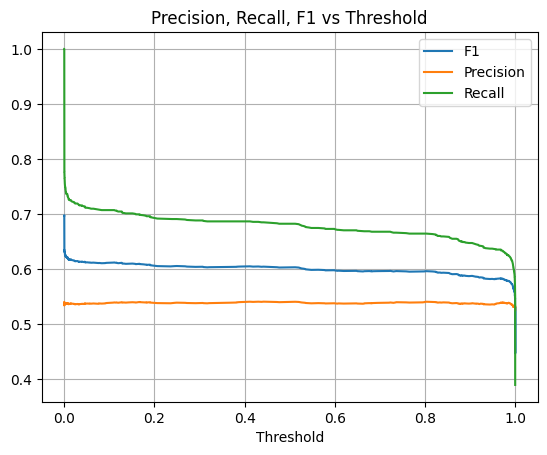

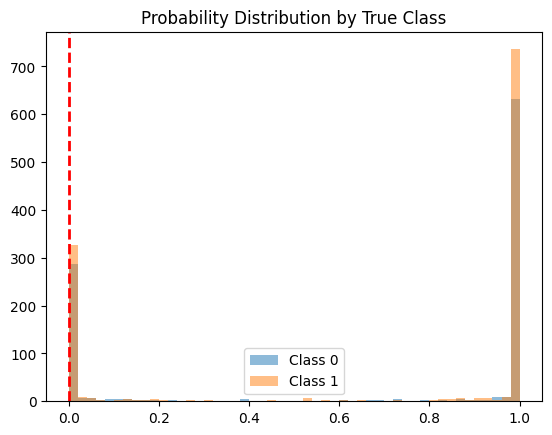

In [ ]:
X_test_tensor, y_test_tensor = tensor_transform(model_preds=df2.copy(), true_labels=Valid_result.copy().to_numpy().T[0])

precision, recall, thresholds = precision_recall_curve(y_test_tensor, y_proba)
f1 = 2 * precision * recall / (precision + recall + 1e-6)

best_threshold = thresholds[np.argmax(f1)]
y_pred_labels = (y_proba > best_threshold).astype(int)

print(f"The best Threshold: {best_threshold}")
print("Predictions:", np.unique(y_pred_labels, return_counts=True))
print("F1-Score:", f1_score(y_pred=y_pred_labels, y_true=y_test_tensor))

plt.plot(thresholds, f1[:-1], label='F1')
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid()
plt.show()

plt.hist(y_proba[y_test_tensor.T[0]==0], bins=50, alpha=0.5, label='Class 0')
plt.hist(y_proba[y_test_tensor.T[0]==1], bins=50, alpha=0.5, label='Class 1')
plt.axvline(x= best_threshold, linestyle="--", linewidth=2, color="red")
plt.legend()
plt.title(f"Probability Distribution by True Class")
plt.show()

In [ ]:
model = LSTM__training(model_preds=df1.copy(), true_labels=y.copy().to_numpy().T[0])
X_test_tensor, y_test_tensor = tensor_transform(model_preds=df1.copy(), true_labels=y.copy().to_numpy().T[0])

model.eval()
with torch.no_grad():
    y_proba_1 = model(X_test_tensor).squeeze().numpy()
    y_pred_1 = (y_proba_1 > 0.5).astype(int)
    
print("Predictions:", np.unique(y_pred_1, return_counts=True))
print("F1-Score:", f1_score(y_pred=y_pred_1, y_true=y_test_tensor))

Epoch 0, Loss: 0.6933
Epoch 100, Loss: 0.6245
Epoch 200, Loss: 0.5882
Epoch 300, Loss: 0.4279
Epoch 400, Loss: 0.2228
Epoch 500, Loss: 0.0687
Epoch 600, Loss: 0.0204
Epoch 700, Loss: 0.0095
Epoch 800, Loss: 0.0056
Early stopping at epoch 878
Predictions: (array([0, 1]), array([4471, 4295]))
F1-Score: 1.0


The best Threshold: 3.6129093170166016
Predictions: (array([0, 1]), array([4472, 4294]))
F1-Score: 0.9998835720107114


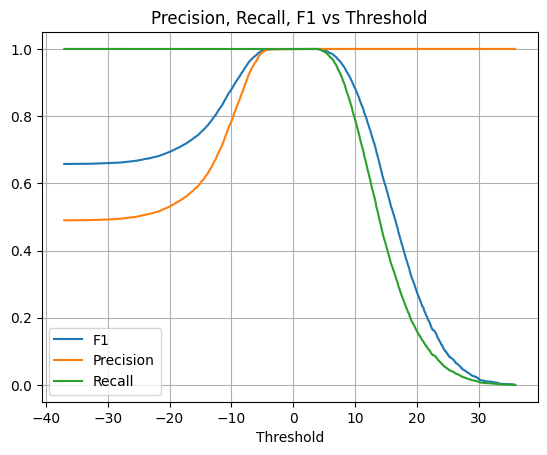

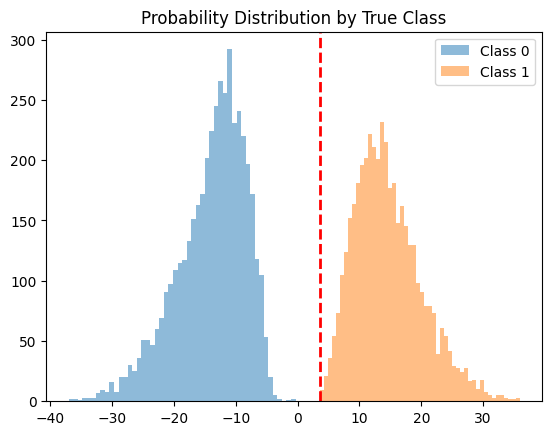

In [ ]:
X_test_tensor, y_test_tensor = tensor_transform(model_preds=df1.copy(), true_labels=y.copy().to_numpy().T[0])

precision, recall, thresholds = precision_recall_curve(y_test_tensor, y_proba_1)
f1 = 2 * precision * recall / (precision + recall + 1e-6)

best_threshold = thresholds[np.argmax(f1)]
y_pred_labels = (y_proba_1 > best_threshold).astype(int)

print(f"The best Threshold: {best_threshold}")
print("Predictions:", np.unique(y_pred_labels, return_counts=True))
print("F1-Score:", f1_score(y_pred=y_pred_labels, y_true=y_test_tensor))

plt.plot(thresholds, f1[:-1], label='F1')
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid()
plt.show()

plt.hist(y_proba_1[y_test_tensor.T[0]==0], bins=50, alpha=0.5, label='Class 0')
plt.hist(y_proba_1[y_test_tensor.T[0]==1], bins=50, alpha=0.5, label='Class 1')
plt.axvline(x= best_threshold, linestyle="--", linewidth=2, color="red")
plt.legend()
plt.title(f"Probability Distribution by True Class")
plt.show()

## HyperTuning:

In [ ]:
from bayes_opt import BayesianOptimization

from bayes_opt import BayesianOptimization
import numpy as np
import torch
from sklearn.metrics import f1_score

def train_model(window_size, lr, l1_lambda):
    window_size = int(window_size)
    lr = float(lr)
    l1_lambda = float(l1_lambda)

    X_train_1 = df1.copy()
    y_train_1 = y.copy()

    f1_array = np.array([])
    for train_idx, val_idx in purged_kfold_split(X_train_1.copy()):
        X_train, X_val = X_train_1.iloc[train_idx, :], X_train_1.iloc[val_idx, :]
        y_train, y_val = y_train_1.iloc[train_idx, :], y_train_1.iloc[val_idx, :]

        # Train model with current hyperparameters
        model = LSTM__training(
            model_preds=X_train,
            true_labels=y_train.copy().to_numpy().T[0],
            window_size=window_size,
            lr=lr,
            l1_lambda=l1_lambda
        ).to(device)

        # Prepare validation tensors
        X_val_tensor, y_val_tensor = tensor_transform(
            model_preds=X_val.copy(),
            true_labels=y_val.copy().to_numpy().T[0],
            window_size=window_size
        )

        # Evaluation
        model.eval()
        with torch.no_grad():
            y_proba = model(X_val_tensor).squeeze().cpu().numpy()
            y_pred = (y_proba > 0.5).astype(int)
            y_val_np = y_val_tensor.cpu().numpy()

        score = f1_score(y_true=y_val_np, y_pred=y_pred)
        f1_array = np.append(f1_array, score)

    return f1_array.mean()

pbounds = {
    'window_size': (10, 50),
    'lr': (1e-4, 1e-2),
    'l1_lambda': (0.0, 0.01)
}

optimizer = BayesianOptimization(
    f=train_model,
    pbounds=pbounds,
    verbose=2,
    random_state=42
)

optimizer.maximize(init_points=5, n_iter=15)

print("\n🔍 Best Parameters:")
print(optimizer.max)

|   iter    |  target   | l1_lambda |    lr     | window... |
-------------------------------------------------------------
Epoch 0, Loss: 34.2673
Epoch 100, Loss: 1.6699
Early stopping at epoch 111
Epoch 0, Loss: 34.2346
Epoch 100, Loss: 1.6724
Early stopping at epoch 111
Epoch 0, Loss: 34.2880
Epoch 100, Loss: 1.6714
Early stopping at epoch 111
Epoch 0, Loss: 34.3528
Epoch 100, Loss: 1.6690
Early stopping at epoch 111
Epoch 0, Loss: 34.3452
Epoch 100, Loss: 1.6723


KeyboardInterrupt: 

## Threshold Tuning:

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test_tensor, y_proba)
f1 = 2 * precision * recall / (precision + recall + 1e-6)

best_threshold = thresholds[np.argmax(f1)]
y_pred_labels = (y_proba > best_threshold).astype(int)
print(f"The best Threshold: {best_threshold}")

plt.plot(thresholds, f1[:-1], label='F1')
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid()
plt.show()

plt.hist(y_proba[y_test_tensor.T[0]==0], bins=50, alpha=0.5, label='Class 0')
plt.hist(y_proba[y_test_tensor.T[0]==1], bins=50, alpha=0.5, label='Class 1')
plt.axvline(x= best_threshold, linestyle="--", linewidth=2, color="red")
plt.legend()
plt.title(f"Probability Distribution by True Class")
plt.show()

print("Predictions:", np.unique(y_pred_labels, return_counts=True))
print("F1-Score:", f1_score(y_pred=y_pred_labels, y_true=y_test_tensor))